# Part 1:引入工具

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers,models
import pandas as pd
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Part 2: 輸入資料

### Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 設定資料路徑
# training data path
trcloudy='/content/drive/MyDrive/weather_image/train/cloudy/'
trrain='/content/drive/MyDrive/weather_image/train/rain/'
trshine='/content/drive/MyDrive/weather_image/train/shine/'
trsunrise='/content/drive/MyDrive/weather_image/train/sunrise/'

# testing data path
testpath='/content/drive/MyDrive/weather_image/test/'

In [4]:
# 顯示資料筆數
print('train cloudy length: ',len(os.listdir(trcloudy)))
print('train rain length: ',len(os.listdir(trrain)))
print('train shine length: ',len(os.listdir(trshine)))
print('train sunrise length: ',len(os.listdir(trsunrise)))
print('\n')
print('test data length: ',len(os.listdir(testpath)))

train cloudy length:  280
train rain length:  199
train shine length:  232
train sunrise length:  337


test data length:  75


### convert image data to numpy

In [5]:
# convert the train data to numpy
tr_label=list()
tr_data=np.empty(shape=(1048,300,300,3))
x=0
for i in range(len(os.listdir(trcloudy))):
  f=os.listdir(trcloudy)[i]
  img=cv2.imread(trcloudy+f)
  img=cv2.resize(img,(300,300))
  img=img[:,:,::-1]/255
  tr_data[x]=img
  tr_label.append(0)
  x+=1
for i in range(len(os.listdir(trrain))):
  f=os.listdir(trrain)[i]
  img=cv2.imread(trrain+f)
  img=cv2.resize(img,(300,300))
  img=img[:,:,::-1]/255
  tr_data[x]=img
  tr_label.append(1)
  x+=1
for i in range(len(os.listdir(trshine))):
  f=os.listdir(trshine)[i]
  img=cv2.imread(trshine+f)
  img=cv2.resize(img,(300,300))
  img=img[:,:,::-1]/255
  tr_data[x]=img
  tr_label.append(2)
  x+=1
for i in range(len(os.listdir(trsunrise))):
  f=os.listdir(trsunrise)[i]
  img=cv2.imread(trsunrise+f)
  img=cv2.resize(img,(300,300))
  img=img[:,:,::-1]/255
  tr_data[x]=img
  tr_label.append(3)
  x+=1

tr_label=np.array(tr_label)

In [6]:
# convert the test data to numpy
te_filename=list()
te_data=np.empty(shape=(75,300,300,3))
for i in range(len(os.listdir(testpath))):
  f=os.listdir(testpath)[i]
  te_filename.append(f)
  img=cv2.imread(testpath+f)
  img=cv2.resize(img,(300,300))
  img=img[:,:,::-1]/255
  te_data[i]=img

In [7]:
# show data size
print('train data size:',tr_data.shape)
print('train label size:',len(tr_label))
print('test data size:',te_data.shape)

train data size: (1048, 300, 300, 3)
train label size: 1048
test data size: (75, 300, 300, 3)


### shuffle

In [8]:
# on-hot label
from tensorflow.keras.utils import to_categorical

# 用 One-Hot 編碼標籤
tr_label = to_categorical(tr_label, num_classes=4)  # 假設有4個類別

# 打亂資料順序
indices = np.random.permutation(tr_data.shape[0])  # 產生隨機順序
tr_data = tr_data[indices]  # 按隨機順序打亂訓練資料
tr_label = tr_label[indices]  # 按隨機順序打亂標籤

### train_validation data split

In [9]:
# train_validation data split
#val_data數量固定262個
# 設定驗證集大小
val_size = 262

# 分割驗證資料和訓練資料
val_data = tr_data[:val_size]
train_data = tr_data[val_size:]
val_label = tr_label[:val_size]
train_label = tr_label[val_size:]

# 檢查分割後的資料形狀
print('train data size: ', train_data.shape)
print('validation data size: ', val_data.shape)
print('train label size: ', train_label.shape)
print('validation label size: ', val_label.shape)


train data size:  (786, 300, 300, 3)
validation data size:  (262, 300, 300, 3)
train label size:  (786, 4)
validation label size:  (262, 4)


### Data augmentation

In [10]:
# Data augmentation

###################### to do ######################
# Data Augmentation
datagen = ImageDataGenerator(
        featurewise_center=False,  # 以每一張feature map為單位將平均值設為0
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # 以每一張feature map為單位將數值除以其標準差(上述兩步驟就是我們常見的Standardization)
        samplewise_std_normalization=False,  #  將输入的每個樣本除以其自身的標準差。
        zca_whitening=False,  # dimesion reduction
        rotation_range=45,  # 隨機旋轉圖片
        zoom_range = 0.5, #  隨機縮放範圍
        width_shift_range=0.15,  #  水平平移，相對總寬度的比例
        height_shift_range=0.15,  # 垂直平移，相對總高度的比例
        shear_range=0.1,
        horizontal_flip=True,  # 一半影象水平翻轉
        vertical_flip=False)  # 一半影象垂直翻轉

datagen.fit(train_data)

# Part 3：建立 CNN 模型

In [11]:
# Build CNN model

###################### to do ######################
#層的定義不能與顯示相同，需要自己建立自己的
# feature extraction 利用cnn.add 加入convolution layer padding MaxPooling
# define model

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix

from keras.models import Sequential, model_from_json
from keras.layers import Dense, Conv2D, Activation, MaxPool2D, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint

# 加強模型層數和複雜度

model = Sequential()

#1. LAYER
model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', input_shape=(300, 300, 3)))
model.add(BatchNormalization())
model.add(Activation("relu"))

#2. LAYER
model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPool2D(pool_size=(2, 2)))

#3. LAYER
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

#4. LAYER
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPool2D(pool_size=(2, 2)))


#FULLY CONNECTED LAYER
model.add(Flatten())
model.add(Dense(256))
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.25))

#OUTPUT LAYER
model.add(Dense(4, activation='softmax'))


In [15]:
# Build compile model

###################### to do ######################
# Define the optimizer
import tensorflow as tf

# Define the optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)

# Compile the model
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

# Display model summary
model.summary()

# Training configuration
epochs = 30
batch_size = 32


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 300, 300, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 300, 300, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 300, 300, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 300, 300, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 300, 300, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 300, 300, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 150, 150, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 150, 150, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 150, 150, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 150, 150, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 150, 150, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 150, 150, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 360000)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      92,160,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 256)                 │              

 Total params: 92,294,436 (352.08 MB)

 Trainable params: 92,293,540 (352.07 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
# Training model

###################### to do ######################

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
checkpointer = ModelCheckpoint(filepath='/content/drive/MyDrive/cnn_model.keras', verbose=0, save_best_only=True)
# 編譯模型
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# 使用 fit 方法進行模型訓練
history = model.fit( datagen.flow(train_data, train_label, batch_size=batch_size),
                    shuffle=True, epochs=epochs, validation_data=(val_data, val_label), verbose=1, steps_per_epoch=train_data.shape[0] // batch_size, callbacks=[checkpointer,] )


print("訓練完成")

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.8404 - loss: 0.4657 - val_accuracy: 0.5687 - val_loss: 1.5494
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 1.0000 - loss: 0.0505 - val_accuracy: 0.5725 - val_loss: 1.4840
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.8547 - loss: 0.3826 - val_accuracy: 0.6756 - val_loss: 1.2246
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8438 - loss: 0.2782 - val_accuracy: 0.6756 - val_loss: 1.2183
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9042 - loss: 0.2684 - val_accuracy: 0.7023 - val_loss: 1.0497
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 1.0000 - loss: 0.1309 - val_accuracy: 0.6947 - val_loss: 1.0367
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 838ms/step - accuracy: 0.8758 - loss: 0.3090 - val_accuracy: 0.7023 - val_loss: 1.0463
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9375 - loss: 0.1740 - val_accuracy: 0.7290 - val_lo

# Part 4:評估模型

### loss curve & accuracy curve

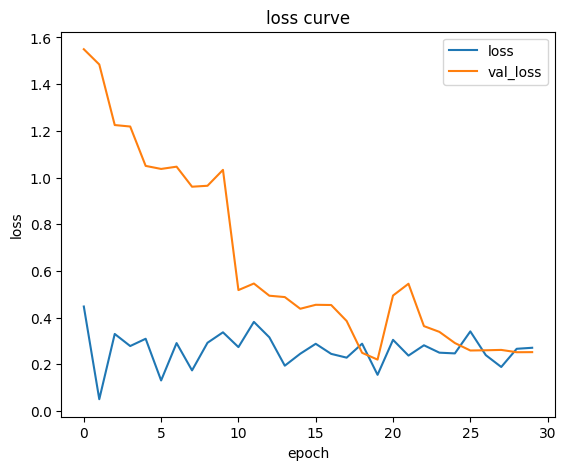

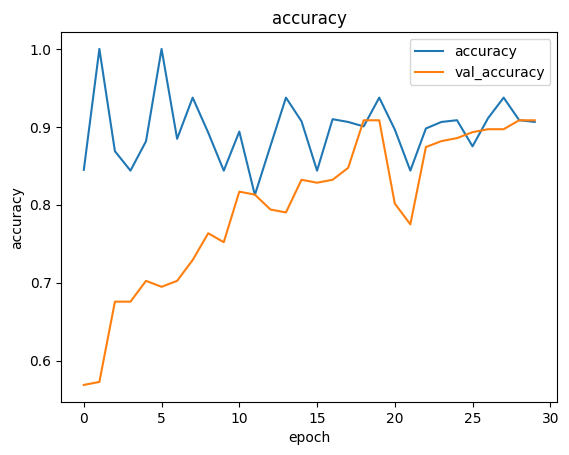

In [17]:
# plot loss curve and accuracy curve

###################### to do ######################
import matplotlib.pyplot as plt

# 繪製訓練和驗證損失
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('loss curve')
plt.show()

# 繪製訓練和驗證準確率
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('accuracy')
plt.show()

### confusion matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


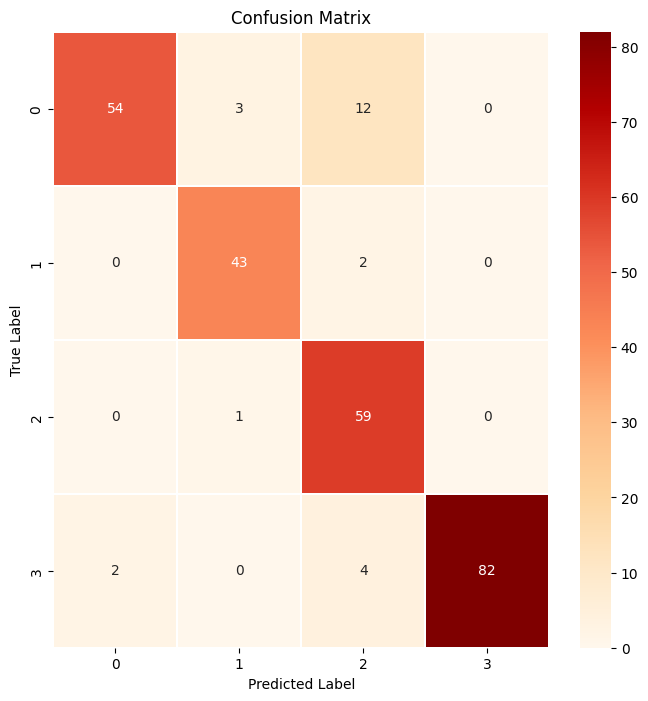

In [22]:
# plot confusion matrix

###################### to do ######################
import seaborn as sns

Y_pred = model.predict(val_data)
Y_pred_classes = np.argmax(Y_pred, axis = 1)
Y_true = np.argmax(val_label, axis = 1)
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

f,ax = plt.subplots(figsize = (8,8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.1, cmap = 'OrRd',fmt='g')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Part 5:將輸出轉成 CSV 檔

In [19]:
import pandas as pd

In [20]:
prediction=model.predict(te_data)
prediction=np.argmax(prediction,axis=1)
prediction

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step


array([2, 3, 1, 3, 3, 2, 2, 0, 1, 0, 0, 2, 2, 2, 2, 3, 1, 1, 0, 1, 0, 3,
       0, 3, 3, 2, 3, 2, 2, 0, 0, 3, 3, 3, 2, 2, 0, 3, 3, 2, 1, 2, 1, 3,
       3, 0, 2, 3, 0, 1, 1, 0, 3, 1, 2, 3, 3, 2, 0, 0, 0, 0, 0, 3, 1, 3,
       3, 1, 2, 0, 1, 0, 2, 1, 1])

In [21]:
test_label=pd.DataFrame()
test_label['image_id']=te_filename
test_label['labels']=prediction
test_label=test_label.sort_values(by='image_id')
test_label.to_csv('/content/drive/MyDrive/weather_image/predict_label.csv',index=False) #結果轉csv檔

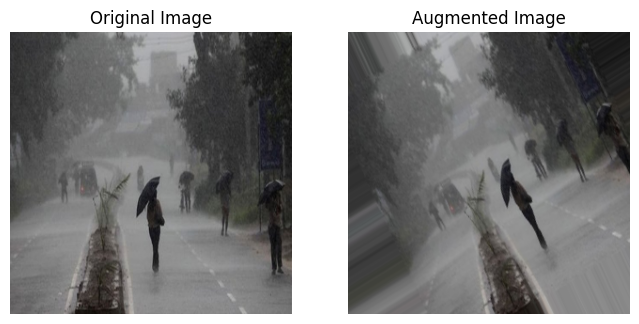

In [26]:
# 任意在訓練資料中找一張圖片，並印出增強後的照片
import matplotlib.pyplot as plt
import numpy as np

# 從訓練資料中隨機選取一張圖片
sample_image = train_data[np.random.randint(0, len(train_data))]

# 增加一個維度，以符合 datagen 的輸入格式 (批次大小, 高度, 寬度, 通道數)
sample_image = np.expand_dims(sample_image, axis=0)

# 使用 datagen 生成增強後的圖片
augmented_image = next(datagen.flow(sample_image, batch_size=1))[0]  # 使用 .flow 生成增強圖片，並去掉批次維度

# 若數值範圍不在 0-1 或 0-255，可以手動縮放至 0-255
augmented_image = np.clip(augmented_image, 0, 1) * 255  # 確保範圍在 0-255 之內
augmented_image = augmented_image.astype(np.uint8)

# 顯示原始圖片和增強後的圖片
plt.figure(figsize=(8, 4))

# 原始圖片
plt.subplot(1, 2, 1)
plt.imshow(sample_image[0])  # 去掉批次維度
plt.title("Original Image")
plt.axis('off')

# 增強後的圖片
plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title("Augmented Image")
plt.axis('off')

plt.show()